# EE519 — Notebook 4: Multimodal Emotion Recognition (Audio + Text)

This notebook is **self-contained** (no dependency on other course notebooks). It loads RAVDESS from `PROJECT_ROOT/data/ravdess`, runs **Whisper ASR**, a **text emotion classifier**, **Wav2Vec2** embeddings + **speaker-independent** SVM, then **late fusion**.

## Why text scores are weak on RAVDESS
Actors speak **two fixed neutral sentences** with different prosody. The **lexical content does not encode emotion**, so text-only emotion models see nearly the same string every time. **Audio must carry the task**; fusion should **not** override confident audio predictions with noisy text.

## Overview
1. **Whisper** ASR (waveform via `librosa` → no `ffmpeg` CLI required)
2. **Hartmann et al.** DistilRoBERTa text emotion (7 classes) mapped **softly** onto RAVDESS 8 classes
3. **Wav2Vec2** + **StratifiedGroupKFold** SVM (subject-independent)
4. **Confidence-weighted** late fusion (text weight shrinks when audio is sure)

### References
- Radford et al. (2022). Whisper. *arXiv*.
- Hartmann (2022). `emotion-english-distilroberta-base` (HuggingFace).
- Baevski et al. (2020). wav2vec 2.0. *NeurIPS*.

In [ ]:
# Self-contained deps (uncomment if needed):
# !pip install openai-whisper transformers torch librosa soundfile scikit-learn matplotlib seaborn tqdm

In [ ]:
import sys
!{sys.executable} -m pip install openai-whisper

In [ ]:
"""Configuration — override with environment variables."""
import os

# Max RAVDESS utterances (speech, normal intensity). 0 or empty = use all (slower).
SER_CLAUDE_MAX_SAMPLES = (os.environ.get("SER_CLAUDE_MAX_SAMPLES") or "400").strip()
WHISPER_SIZE = os.environ.get("SER_WHISPER_MODEL", "base")  # tiny, base, small, ...
WAV2VEC_MODEL = "facebook/wav2vec2-base-960h"
TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
RANDOM_STATE = 42
# Floor for audio weight in fusion (0.82–1.0): higher => trust audio more on RAVDESS.
FUSION_AUDIO_FLOOR = float(os.environ.get("SER_NB4_FUSION_AUDIO_FLOOR", "0.88"))

import glob
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import whisper
from collections import Counter
from tqdm import tqdm
from pathlib import Path

from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

from transformers import pipeline, Wav2Vec2FeatureExtractor, Wav2Vec2Model

import warnings
warnings.filterwarnings("ignore")

torch.set_grad_enabled(False)
print("Config:", {"MAX_SAMPLES": SER_CLAUDE_MAX_SAMPLES, "WHISPER": WHISPER_SIZE, "FUSION_FLOOR": FUSION_AUDIO_FLOOR})

## 1. Load RAVDESS metadata

Filename: `03-01-EM-...-ACTOR.wav` — we use **actor** (speaker id) for **subject-independent** CV.

In [ ]:
import numpy as np

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name in ("notebooks_claude", "notebooks")
    else NOTEBOOK_DIR
)
RAVDESS_DIR = PROJECT_ROOT / "data" / "ravdess"
assert RAVDESS_DIR.is_dir(), f"Missing {RAVDESS_DIR} — run scripts/download_kaggle_ravdess.py"
_wavs = list(RAVDESS_DIR.glob("**/*.wav"))
assert _wavs, f"No WAV files under {RAVDESS_DIR}"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAVDESS_DIR:", RAVDESS_DIR, "| wav count:", len(_wavs))

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_ravdess(fp: str):
    parts = Path(fp).stem.split("-")
    return {
        "filepath": fp,
        "emotion": EMOTION_MAP.get(parts[2], "unknown"),
        "actor_id": int(parts[6]),
    }

audio_files = sorted(glob.glob(str(RAVDESS_DIR / "**" / "*.wav"), recursive=True))
data = [
    parse_ravdess(f)
    for f in audio_files
    if Path(f).name.split("-")[0] == "03" and Path(f).name.split("-")[1] == "01"
]
print(f"Utterances (speech, normal intensity): {len(data)}")

cap = SER_CLAUDE_MAX_SAMPLES
if data and cap not in ("", "0") and len(data) > int(cap):
    rng = np.random.default_rng(RANDOM_STATE)
    pick = rng.choice(len(data), size=int(cap), replace=False)
    data = [data[i] for i in pick]
    print(f"Random subset: {len(data)} files (set SER_CLAUDE_MAX_SAMPLES=0 for full set)")

print("Speakers in subset:", len({d['actor_id'] for d in data}))

## 2. Whisper ASR (librosa → waveform, no ffmpeg)

We pass a **16 kHz float32** waveform into `whisper.transcribe` so decoding does not call the `ffmpeg` binary. An **initial prompt** nudges recognition toward the two RAVDESS sentences.

In [5]:
RAVDESS_PROMPT = (
    "Kids are talking by the door. Dogs are sitting by the door."
)

whisper_model = whisper.load_model(WHISPER_SIZE)
print("Whisper loaded:", WHISPER_SIZE)

def transcribe_whisper(path: str) -> str:
    wav = librosa.load(path, sr=16000, mono=True)[0].astype(np.float32)
    audio = whisper.pad_or_trim(wav)
    out = whisper_model.transcribe(
        audio,
        language="en",
        fp16=False,
        initial_prompt=RAVDESS_PROMPT,
        condition_on_previous_text=False,
    )
    return (out.get("text") or "").strip()

transcripts = []
for d in tqdm(data, desc="Whisper"):
    try:
        tx = transcribe_whisper(d["filepath"])
    except Exception as e:
        tx = ""
    transcripts.append(
        {
            "filepath": d["filepath"],
            "emotion": d["emotion"],
            "actor_id": d["actor_id"],
            "text": tx,
        }
    )

for t in transcripts[:8]:
    print(f"  [{t['emotion']:>10s}] {t['text'][:90]}")

Whisper loaded: base


Whisper: 100%|██████████| 400/400 [03:33<00:00,  1.87it/s]

  [       sad] Kids are talking by the door.
  [   disgust] Kids are talking by the door.
  [   disgust] Dogs are sitting by the door.
  [   fearful] Dogs are sitting by the door.
  [      calm] Kids are talking by the door.
  [   fearful] Kids are talking by the door.
  [   disgust] Kids are talking by the door.
  [   neutral] Kids are talking by the door.


## 3. Text emotion → RAVDESS probability vector

The Hartmann model outputs **7** labels (`anger`, `disgust`, `fear`, `joy`, `neutral`, `sadness`, `surprise`). RAVDESS has **8** classes including **calm**. We map **neutral** text mass **split** between `neutral` and `calm` (soft label propagation). All model labels are lowercased for matching.

In [6]:
RAVDESS_EMOTIONS = sorted(EMOTION_MAP.values())

# Soft mapping: each Hartmann label distributes probability mass over RAVDESS classes (sums to 1 per label).
HARTMANN_TO_RAVDESS = {
    "anger": {"angry": 1.0},
    "disgust": {"disgust": 1.0},
    "fear": {"fearful": 1.0},
    "joy": {"happy": 1.0},
    "neutral": {"neutral": 0.5, "calm": 0.5},
    "sadness": {"sad": 1.0},
    "surprise": {"surprised": 1.0},
}

text_clf = pipeline(
    "text-classification",
    model=TEXT_MODEL,
    top_k=None,
    truncation=True,
)

def text_scores_to_ravdess_proba(result_list):
    """result_list: [{'label': '...', 'score': float}, ...] from top_k=None."""
    vec = np.zeros(len(RAVDESS_EMOTIONS), dtype=np.float64)
    for r in result_list:
        lab = str(r["label"]).lower().strip()
        s = float(r["score"])
        if lab not in HARTMANN_TO_RAVDESS:
            continue
        for emo, w in HARTMANN_TO_RAVDESS[lab].items():
            vec[RAVDESS_EMOTIONS.index(emo)] += s * w
    if vec.sum() < 1e-10:
        vec[RAVDESS_EMOTIONS.index("neutral")] = 1.0
    else:
        vec /= vec.sum()
    return vec

text_proba = np.zeros((len(transcripts), len(RAVDESS_EMOTIONS)))
for i, t in enumerate(tqdm(transcripts, desc="Text emotion")):
    if not t["text"]:
        text_proba[i, RAVDESS_EMOTIONS.index("neutral")] = 1.0
        continue
    try:
        raw = text_clf(t["text"][:512])
        text_proba[i] = text_scores_to_ravdess_proba(raw[0])
    except Exception:
        text_proba[i, RAVDESS_EMOTIONS.index("neutral")] = 1.0

text_preds = [RAVDESS_EMOTIONS[i] for i in np.argmax(text_proba, axis=1)]
print("Text argmax distribution:", dict(Counter(text_preds)))

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 26320.94it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Text emotion: 100%|██████████| 400/400 [00:06<00:00, 64.03it/s]

Text argmax distribution: {'calm': 399, 'surprised': 1}


## 4. Wav2Vec2 embeddings + subject-independent SVM

Same protocol as the SSL notebook: **last layer, mean pool**, **RBF SVM** with **StratifiedGroupKFold** on **actor_id**.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
w2v2_fe = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC_MODEL)
w2v2_model = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL).to(device).eval()

def get_w2v2_emb(path: str) -> np.ndarray:
    y, orig_sr = librosa.load(path, sr=None, mono=True)
    if orig_sr != 16000:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=16000)
    inputs = w2v2_fe(y, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        out = w2v2_model(**{k: v.to(device) for k, v in inputs.items()})
    return out.last_hidden_state.squeeze(0).mean(dim=0).cpu().numpy()

X_audio, y_audio, groups = [], [], []
for t in tqdm(transcripts, desc="Wav2Vec2"):
    try:
        X_audio.append(get_w2v2_emb(t["filepath"]))
        y_audio.append(t["emotion"])
        groups.append(t["actor_id"])
    except Exception as e:
        print("embed skip:", e)

X_audio = np.asarray(X_audio, dtype=np.float32)
y_audio = np.asarray(y_audio)
groups = np.asarray(groups, dtype=np.int64)
print("Audio matrix:", X_audio.shape, "| speakers:", len(np.unique(groups)))

Loading weights: 100%|██████████| 210/210 [00:00<00:00, 7260.77it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Wav2Vec2: 100%|██████████| 400/400 [01:25<00:00,  4.67it/s]

Audio matrix: (400, 768) | speakers: 24


## 5. Evaluation + confidence-weighted fusion

- **Audio**: `cross_val_predict` with `StratifiedGroupKFold` + `groups=actor_id`.
- **Fusion**: `α` increases with **max audio softmax** so text cannot override a confident acoustic prediction (critical on RAVDESS).
- **Baseline**: `α = 1` reproduces audio-only (useful when text is uninformative).

In [8]:
le = LabelEncoder()
le.fit(RAVDESS_EMOTIONS)
y_enc = le.transform(y_audio)

n_spk = len(np.unique(groups))
n_splits = min(5, n_spk)
if n_splits < 2:
    raise ValueError("Need ≥2 speakers in subset for subject-independent CV.")

cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"Subject-independent CV: n_splits={n_splits}, speakers={n_spk}")

svm_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=5.0,
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

audio_proba = cross_val_predict(svm_pipe, X_audio, y_enc, cv=cv, groups=groups, method="predict_proba")
audio_preds = le.inverse_transform(np.argmax(audio_proba, axis=1))

# Align text rows to same order as audio (already aligned via transcripts)
assert text_proba.shape[0] == audio_proba.shape[0]

# Confidence-weighted fusion: alpha in [FUSION_AUDIO_FLOOR, 1.0]
a_conf = audio_proba.max(axis=1, keepdims=True)
alpha = FUSION_AUDIO_FLOOR + (1.0 - FUSION_AUDIO_FLOOR) * a_conf
fused_proba = alpha * audio_proba + (1.0 - alpha) * text_proba
fused_preds = le.inverse_transform(np.argmax(fused_proba, axis=1))

true_labels = y_audio

def report(name, preds):
    uar = balanced_accuracy_score(true_labels, preds)
    acc = accuracy_score(true_labels, preds)
    print(f"\n{name}")
    print(f"  UAR: {uar:.4f}  |  Accuracy: {acc:.4f}")
    print(classification_report(true_labels, preds, labels=RAVDESS_EMOTIONS, zero_division=0))

print("=" * 60)
report("Audio only (Wav2Vec2 + SVM, speaker-independent CV)", audio_preds)
report("Text only (mapped to RAVDESS)", text_preds)
report(f"Fused (adaptive α, floor={FUSION_AUDIO_FLOOR})", fused_preds)
print("=" * 60)
print("Mean α:", float(alpha.mean()), "(higher ⇒ more weight on audio)")

Subject-independent CV: n_splits=5, speakers=24

Audio only (Wav2Vec2 + SVM, speaker-independent CV)
  UAR: 0.2994  |  Accuracy: 0.3425
              precision    recall  f1-score   support

       angry       0.44      0.59      0.50        58
        calm       0.46      0.58      0.51        66
     disgust       0.30      0.27      0.28        49
     fearful       0.33      0.37      0.35        52
       happy       0.15      0.08      0.11        48
     neutral       0.00      0.00      0.00        19
         sad       0.26      0.16      0.20        49
   surprised       0.25      0.36      0.29        59

    accuracy                           0.34       400
   macro avg       0.28      0.30      0.28       400
weighted avg       0.31      0.34      0.32       400


Text only (mapped to RAVDESS)
  UAR: 0.1271  |  Accuracy: 0.1675
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        58
        calm       0.17      1.00     

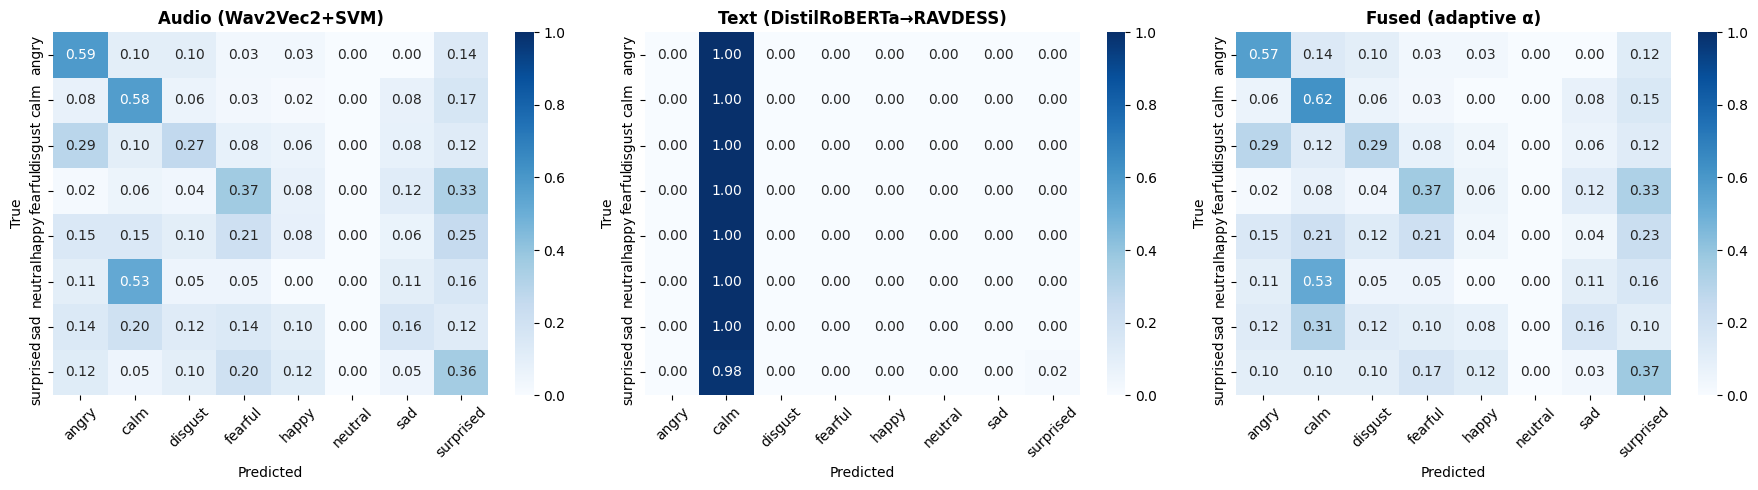

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in [
    (axes[0], audio_preds, "Audio (Wav2Vec2+SVM)"),
    (axes[1], text_preds, "Text (DistilRoBERTa→RAVDESS)"),
    (axes[2], fused_preds, "Fused (adaptive α)"),
]:
    cm = confusion_matrix(true_labels, preds, labels=RAVDESS_EMOTIONS, normalize="true")
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=RAVDESS_EMOTIONS,
        yticklabels=RAVDESS_EMOTIONS,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Takeaways

- On **RAVDESS**, **audio** should match or beat **fusion** if the pipeline is correct — text is a sanity check, not a second strong modality.
- If **fused** lags **audio**, lower text influence by raising `SER_NB4_FUSION_AUDIO_FLOOR` (e.g. `0.95`) or set fusion to audio-only (`α=1`).
- For datasets where **word content** varies (IEMOCAP, MELD), increase text weight or learn **α** on a validation split.
- **Next steps**: attention-based fusion, or a small **end-to-end** classifier on concatenated embeddings (Wav2Vec2 + text encoder).